In [1]:
# Stock market with ML

Downlaoding S&P 500 price data

In [2]:
import yfinance as yf # gets daily stocks and index prices

In [3]:
sp500 = yf.Ticker("^GSPC") # trying to get a Ticker object for the S&P 500 index itself

In [4]:
sp500 = sp500.history(period= "max") # gets me data starting from when the qyery was first created

In [5]:
sp500.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [6]:
sp500.index

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2026-08-19 00:00:00-04:00', '2026-08-20 00:00:00-04:00',
               '2026-08-21 00:00:00-04:00', '2026-08-24 00:00:00-04:00',
               '2026-08-25 00:00:00-04:00', '2026-08-26 00:00:00-04:00',
               '2026-08-27 00:00:00-04:00', '2026-08-31 00:00:00-04:00',
               '2026-09-01 00:00:00-04:00', '2026-09-02 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24784, freq=None)

Cleaning and Visualizing our Stock market data

<Axes: xlabel='Date'>

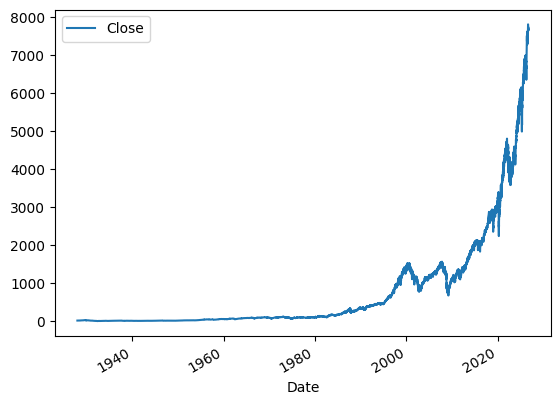

In [7]:
sp500.plot.line(y= "Close", use_index= True)

In [8]:
del sp500["Dividends"]
del sp500["Stock Splits"]

setting up target for **ML**

In [9]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000


In [10]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int) # 1 if the price went up the next day, 0 if it didn't. This turns "predict the future" into a binary classification problem
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0


In [11]:
sp500 = sp500.loc["1990-01-01":].copy() # removing data before 1990
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0


initial ML model

In [12]:
from sklearn.ensemble import RandomForestClassifier
# A random forest is a collection of many decision trees, each trained on a slightly different random subset of the data, that vote on the final answer.

model = RandomForestClassifier(n_estimators= 100, min_samples_split= 100, random_state= 1)
# n_estimators= 100: This is how many trees are in the forest. More trees = generally more stable predictions (less random noise in the outcome)
# min_samples_split= 100: This controls how cautious each tree is about splitting a branch
# random_state= 1: just a seed for reproducibility — random forests involve a lot of randomness (which data subset each tree sees, which features it considers at each split).

train = sp500.iloc[:-100] # everything except the last 100 rows
test = sp500.iloc[-100:] # just the last 100 rows

predictors = ["Close", "Volume", "Open", "High", "Low"] # train on these params
model.fit(train[predictors], train["Target"]) # use predictors params for Target

RandomForestClassifier(min_samples_split=100, random_state=1)

In [13]:
from sklearn.metrics import precision_score
import pandas as pd

preds = model.predict(test[predictors]) # Runs the trained model on the test set

preds = pd.Series(preds, index= test.index) # Wraps the raw array back into a pandas Series, using the same dates as test
precision_score(test["Target"], preds) # Compares your predictions against the real Target values and computes precision.

1.0

<Axes: xlabel='Date'>

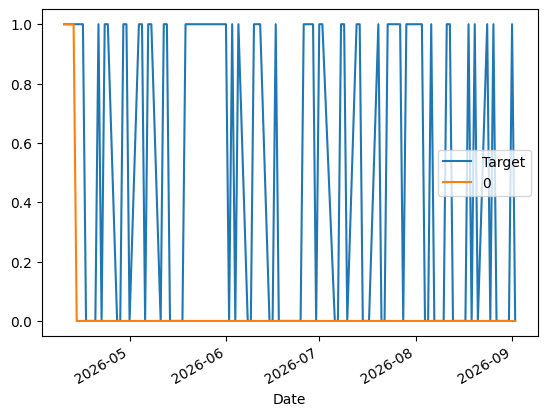

In [14]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

building a backtesting system

In [15]:
def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds= model.predict(test[predictors])
  preds= pd.Series(preds, index= test.index, name= "Predictions")
  combined= pd.concat([test["Target"], preds], axis=1)
  return combined

In [16]:
# backtesting: Instead of testing once, this tests the model over and over, many times, moving forward through history

def backtest(data, model, predictors, start= 2500, step= 250):
  all_predictions= []

  for i in range(start, data.shape[0], step):
    # First train on everything up to row 2500, test on the next 250 rows.
    # Then train on everything up to row 2750 (now including what was just the test set),
    #test on the next 250 rows. And so on, all the way to the end of the data.
    train= data.iloc[0:i].copy()
    test= data.iloc[i:(i+step)].copy()
    predictions= predict(train, test, predictors, model) # Each iteration produces one window's worth of predictions
    all_predictions.append(predictions)
  return pd.concat(all_predictions) # Stitches every window's results into one long DataFrame

In [17]:
predictions = backtest(sp500, model, predictors)

In [18]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,4053
1,2681


In [19]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5311450951137635

add more predictors to our model

In [20]:
horizons = [2, 5, 60, 250, 1000]
new_predictors = []

for horizon in horizons: # For each horizon (2 days, 5 days, 60 days, 250 days [~1 year], 1000 days [~4 years]), compute the rolling average of every column over that window.
  rolling_averages = sp500.rolling(horizon).mean() # taking average of a few days

  ratio_columns = f"Close_Ratio_{horizon}"
  sp500[ratio_columns] = sp500["Close"] / rolling_averages["Close"] # Today's actual price ÷ that average

  trend_columns = f"Trend_{horizon}"
  sp500[trend_columns] = sp500.shift(1).rolling(horizon).sum()["Target"]
  # .shift(1) — nudge everything down by one day

  new_predictors += [ratio_columns, trend_columns]

In [21]:
sp500 = sp500.dropna(subset=["Tomorrow"])
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-25 00:00:00-04:00,7676.660156,7686.109863,7650.919922,7677.279785,4260240000,7675.700195,0,1.001593,1.0,1.000854,3.0,1.018717,30.0,1.094281,141.0,1.399170,546.0
2026-08-26 00:00:00-04:00,7666.879883,7690.729980,7657.410156,7675.700195,4100600000,7730.990234,1,0.999897,1.0,1.001491,2.0,1.018337,29.0,1.093311,140.0,1.397942,546.0
2026-08-27 00:00:00-04:00,7710.339844,7741.270020,7689.890137,7730.990234,4362240000,7686.140137,0,1.003589,1.0,1.006346,3.0,1.025398,29.0,1.100416,140.0,1.407044,547.0


Improving our model

In [22]:
model = RandomForestClassifier(n_estimators= 200, min_samples_split= 50, random_state= 1)

def predict(train, test, predictors, model):
  model.fit(train[predictors], train["Target"])
  preds= model.predict_proba(test[predictors])[:,1]
  preds [preds >= .6 ] = 1
  preds [preds < .6 ] = 0
  preds= pd.Series(preds, index= test.index, name= "Predictions")
  combined= pd.concat([test["Target"], preds], axis=1)
  return combined

In [23]:
predictions = backtest(sp500, model, new_predictors)

In [24]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,5676
1.0,1057


In [25]:
precision_score(predictions["Target"], predictions["Predictions"])

0.543046357615894